In [ ]:
import sys
from pathlib import Path

def find_project_root():
    current = Path().resolve()
    for parent in [current] + list(current.parents):
        if (parent / "config" / "paths.py").exists():
            return parent
    raise FileNotFoundError("프로젝트 루트를 찾을 수 없음")

sys.path.append(str(find_project_root()))
from config.paths import PROJECT_ROOT, DATA_DIR, OUTPUTS_DIR, MODELS_DIR

## 0. 환경 설정

In [1]:
import os, sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

# 한글 폰트 (Malgun Gothic) 설정
for f in font_manager.fontManager.ttflist:
    if "Malgun" in f.name:
        mpl.rcParams["font.family"] = f.name
        break
mpl.rcParams["axes.unicode_minus"] = False

# 경로
ROOT = Path("C:/Users/user/Desktop/PROJ2")
DATA_DIR = ROOT / "track_a_data"
YOLO_CSV = ROOT / "yolo_inference_results.csv"
OUT_PROFILE = ROOT / "defect_profile_table.csv"
OUT_RESULT_JSON = ROOT / "_profile_result.json"

print("pandas:", pd.__version__)
print("matplotlib:", mpl.__version__)
print("ROOT:", ROOT)


pandas: 3.0.2
matplotlib: 3.10.8
ROOT: C:\Users\user\Desktop\PROJ2


## Step 1 - 데이터 로드 및 확인

### 로드 대상
| 파일 | 용도 |
|---|---|
| `yolo_inference_results.csv` | Phase 1-B 산출물 — YOLO 탐지 280행 (탐지 243건 + 빈 이미지 더미 37행) |
| `defect_detail.csv` | 정형 결함 이력 170,904행 |
| `inspection_master.csv` | 검사 마스터 3,000,000행 (필요 컬럼만 선택 로드) |
| `master_defect_type.csv` | 결함 마스터 (severity, std_rework_time_min) |
| `master_zone.csv` | 구역 마스터 (한글명) |


In [2]:
# 1-1. YOLO 탐지 결과
yolo_raw = pd.read_csv(YOLO_CSV, encoding="utf-8-sig")
print("yolo_raw shape:", yolo_raw.shape)

# 결함 없는 이미지(class_id NaN) 분리
yolo_empty = yolo_raw[yolo_raw["class_id"].isna()].copy()
yolo_df = yolo_raw[yolo_raw["class_id"].notna()].copy()
print(f"  탐지 있는 행: {len(yolo_df)}건  /  빈 이미지 행: {len(yolo_empty)}건")
print(f"  unique 이미지 수: {yolo_raw['image_file'].nunique()}장 (val 200장 커버리지)")


yolo_raw shape: (289, 16)
  탐지 있는 행: 251건  /  빈 이미지 행: 38건
  unique 이미지 수: 200장 (val 200장 커버리지)


In [3]:
# 1-2. defect_type / zone 분포 (탐지 결과)
print("[YOLO 탐지 결과 - defect_type 분포]")
print(yolo_df["defect_type_code"].value_counts())
print()
print("[YOLO 탐지 결과 - zone(이미지명 기준) 분포]")
print(yolo_df["zone"].value_counts())


[YOLO 탐지 결과 - defect_type 분포]
defect_type_code
SCR    65
DNT    48
DST    34
PBB    31
GAP    30
ORG    23
PDR    15
CRK     5
Name: count, dtype: int64

[YOLO 탐지 결과 - zone(이미지명 기준) 분포]
zone
rocker        41
fender        40
bumper        35
trunk         33
hood          32
rear_door     27
front_door    22
roof          21
Name: count, dtype: int64


In [4]:
# 1-3. 마스터 테이블
master_defect = pd.read_csv(DATA_DIR / "master_defect_type.csv", encoding="utf-8-sig")
master_zone   = pd.read_csv(DATA_DIR / "master_zone.csv",        encoding="utf-8-sig")
print("master_defect_type:", master_defect.shape)
display(master_defect)
print("master_zone:", master_zone.shape)
display(master_zone)


master_defect_type: (10, 4)


,defect_type_code,defect_type_name,severity,std_rework_time_min
0,SCR,스크래치,MINOR,15
1,DNT,덴트,MAJOR,45
2,PBB,도장기포,MINOR,30
3,PDR,도장흘림,MINOR,25
4,GAP,Gap불량,CRITICAL,60
5,DST,이물질,MINOR,10
6,ORG,오렌지필,MINOR,20
7,CRK,크랙,CRITICAL,90
8,CLP,클립마크,MINOR,15
9,WLD,용접불량,CRITICAL,120


master_zone: (12, 2)


,zone_code,zone_name
0,HOOD,후드
1,FF,프론트펜더
2,FD,프론트도어
3,RD,리어도어
4,RF,리어펜더
5,TRUNK,트렁크
6,ROOF,루프
7,ROCKER,로커패널
8,BUMPER_F,프론트범퍼
9,BUMPER_R,리어범퍼


In [5]:
# 1-4. defect_detail 로드
defect_detail = pd.read_csv(
    DATA_DIR / "defect_detail.csv",
    encoding="utf-8-sig",
    dtype={
        "defect_id": "string",
        "inspection_id": "string",
        "defect_type_code": "category",
        "severity": "category",
        "zone_code": "category",
        "rework_required": "category",
    },
)
print("defect_detail:", defect_detail.shape)
print("컬럼:", list(defect_detail.columns))


defect_detail: (170904, 17)
컬럼: ['defect_id', 'inspection_id', 'body_number', 'defect_type_code', 'defect_type_name', 'severity', 'zone_code', 'zone_name', 'x_position_mm', 'y_position_mm', 'width_mm', 'height_mm', 'area_mm2', 'confidence', 'rework_required', 'estimated_rework_min', 'detection_datetime']


In [6]:
# 1-5. inspection_master — 필요 컬럼만 (메모리 절약)
need_cols = [
    "inspection_id", "shift", "inspection_datetime",
    "humidity_pct", "ambient_temp_c",
    "plant_code", "line_code",
]
inspection_master = pd.read_csv(
    DATA_DIR / "inspection_master.csv",
    encoding="utf-8-sig",
    usecols=need_cols,
    dtype={
        "inspection_id": "string",
        "shift": "category",
        "plant_code": "category",
        "line_code": "category",
        "humidity_pct": "float32",
        "ambient_temp_c": "float32",
    },
)
print("inspection_master:", inspection_master.shape)
print("메모리:", round(inspection_master.memory_usage(deep=True).sum() / 1e6, 1), "MB")


inspection_master: (3000000, 7)


메모리: 423.0 MB


In [7]:
# 1-6. defect_detail ⨝ inspection_master (left join)
# inspection_datetime → hour 추출
inspection_master["inspection_datetime"] = pd.to_datetime(
    inspection_master["inspection_datetime"], errors="coerce"
)
inspection_master["hour"] = inspection_master["inspection_datetime"].dt.hour.astype("int8")

defect_df = defect_detail.merge(
    inspection_master[[
        "inspection_id", "shift", "hour",
        "humidity_pct", "ambient_temp_c",
        "plant_code", "line_code",
    ]],
    on="inspection_id", how="left",
)
print("defect_df shape:", defect_df.shape)
print("결측 검사:")
print(defect_df[["shift", "hour", "humidity_pct"]].isna().sum())

# inspection_master 객체는 더 이상 사용 안 함 → 메모리 해제
del inspection_master
import gc; gc.collect()
print("inspection_master 메모리 해제 완료")


defect_df shape: (170904, 23)
결측 검사:
shift           0
hour            0
humidity_pct    0
dtype: int64
inspection_master 메모리 해제 완료


## Step 2 - 매핑 테이블 정의

이미지 dataset 의 zone 이름은 영문 소문자(`hood`, `front_door` …)이고,
정형 DB 의 `zone_code` 는 대문자 코드(`HOOD`, `FD` …) 다.
1:1 매핑이 명확한 6개와 1:2 모호한 2개(bumper, fender)를 구분해 표시한다.

### 신뢰도 등급
- **확정 (1:1)**: hood, front_door, rear_door, roof, trunk, rocker
- **모호 (1:2)**: bumper → BUMPER_F + BUMPER_R / fender → FF + RF
- **누락**: QTR_L, QTR_R 은 이미지 데이터셋에 촬영본 없음


In [8]:
# 2-1. zone 매핑 (이미지 → 정형 DB)
zone_mapping = {
    "hood":       ["HOOD"],
    "front_door": ["FD"],
    "rear_door":  ["RD"],
    "roof":       ["ROOF"],
    "trunk":      ["TRUNK"],
    "rocker":     ["ROCKER"],
    "bumper":     ["BUMPER_F", "BUMPER_R"],   # 1:2 모호
    "fender":     ["FF", "RF"],               # 1:2 모호
    # QTR_L, QTR_R 은 이미지에 없음 → 매핑 없음
}

mapping_quality = {
    "hood": "확정", "front_door": "확정", "rear_door": "확정",
    "roof": "확정", "trunk": "확정", "rocker": "확정",
    "bumper": "모호(1:2)", "fender": "모호(1:2)",
}

zm_df = pd.DataFrame([
    {"image_zone": k, "zone_codes": ",".join(v),
     "n_codes": len(v), "신뢰도": mapping_quality[k]}
    for k, v in zone_mapping.items()
])
display(zm_df)
print()
print("미매핑(이미지에 없음): QTR_L, QTR_R")


,image_zone,zone_codes,n_codes,신뢰도
0,hood,HOOD,1,확정
1,front_door,FD,1,확정
2,rear_door,RD,1,확정
3,roof,ROOF,1,확정
4,trunk,TRUNK,1,확정
5,rocker,ROCKER,1,확정
6,bumper,"BUMPER_F,BUMPER_R",2,모호(1:2)
7,fender,"FF,RF",2,모호(1:2)



미매핑(이미지에 없음): QTR_L, QTR_R


## Step 3 - 프로파일 테이블 구축 (핵심)

`defect_type_code × zone_code` 조합별로 다음 필드를 집계한다.
이 테이블이 YOLO 탐지 결과의 조회 대상이 된다.

### 집계 필드
- **샘플 수**: `n_samples`
- **교대조 분포**: `shift_A_ratio`, `shift_B_ratio`, `shift_C_ratio`, `dominant_shift`
- **시간대**: `peak_hour`, `shift_start_ratio` (06/14/22시)
- **환경**: `avg_humidity`, `low_humidity_ratio` (<25%), `avg_temp`
- **재작업**: `avg_rework_min`, `total_rework_min`, `rework_required_ratio`
- **심각도**: 단일값 (defect_type 으로 결정됨)


In [9]:
# 3-1. 프로파일 집계 — defect_type x zone
# 주의: 카테고리 dtype + 동일이름(severity) 출력 시 pandas 가 KeyError 를 내는 케이스가 있어
#       severity 는 별도로 master_defect_type 에서 join 으로 가져옴.
def _mode_first(s):
    m = s.mode(dropna=True)
    return m.iloc[0] if len(m) else np.nan

# 카테고리 컬럼 → 문자열 변환 (groupby 안정성)
_dd = defect_df.copy()
_dd["shift"]           = _dd["shift"].astype("string")
_dd["rework_required"] = _dd["rework_required"].astype("string")

profile_df = (
    _dd
    .groupby(["defect_type_code", "zone_code"], observed=True)
    .agg(
        n_samples            = ("defect_id",            "count"),
        shift_A_ratio        = ("shift",                lambda x: (x == "A").mean()),
        shift_B_ratio        = ("shift",                lambda x: (x == "B").mean()),
        shift_C_ratio        = ("shift",                lambda x: (x == "C").mean()),
        dominant_shift       = ("shift",                _mode_first),
        peak_hour            = ("hour",                 _mode_first),
        shift_start_ratio    = ("hour",                 lambda x: x.isin([6, 14, 22]).mean()),
        avg_humidity         = ("humidity_pct",         "mean"),
        low_humidity_ratio   = ("humidity_pct",         lambda x: (x < 25).mean()),
        avg_temp             = ("ambient_temp_c",       "mean"),
        avg_rework_min       = ("estimated_rework_min", "mean"),
        total_rework_min     = ("estimated_rework_min", "sum"),
        rework_required_ratio= ("rework_required",      lambda x: (x == "Y").mean()),
    )
    .reset_index()
)
del _dd
print("profile_df shape:", profile_df.shape)


profile_df shape: (120, 15)


In [10]:
# 3-2. master_defect_type 조인 (한글명, severity, std_rework_time_min)
profile_df = profile_df.merge(
    master_defect[["defect_type_code", "defect_type_name", "severity", "std_rework_time_min"]],
    on="defect_type_code", how="left",
)
# zone_code 도 string 으로 안전 변환
profile_df["zone_code"] = profile_df["zone_code"].astype(str)
profile_df["defect_type_code"] = profile_df["defect_type_code"].astype(str)

# 컬럼 순서 정리
order = [
    "defect_type_code", "defect_type_name", "zone_code", "severity",
    "n_samples",
    "shift_A_ratio", "shift_B_ratio", "shift_C_ratio", "dominant_shift",
    "peak_hour", "shift_start_ratio",
    "avg_humidity", "low_humidity_ratio", "avg_temp",
    "avg_rework_min", "total_rework_min", "rework_required_ratio",
    "std_rework_time_min",
]
profile_df = profile_df[order]
print("최종 컬럼:", list(profile_df.columns))


최종 컬럼: ['defect_type_code', 'defect_type_name', 'zone_code', 'severity', 'n_samples', 'shift_A_ratio', 'shift_B_ratio', 'shift_C_ratio', 'dominant_shift', 'peak_hour', 'shift_start_ratio', 'avg_humidity', 'low_humidity_ratio', 'avg_temp', 'avg_rework_min', 'total_rework_min', 'rework_required_ratio', 'std_rework_time_min']


In [11]:
# 3-3. 저장 + 검증 출력
profile_df.to_csv(OUT_PROFILE, index=False, encoding="utf-8-sig")
print(f"저장: {OUT_PROFILE}")
print()
print(f"profile_df.shape : {profile_df.shape}")
print(f"n_samples 최소   : {profile_df['n_samples'].min()}")
print(f"n_samples 최대   : {profile_df['n_samples'].max()}")
print(f"n_samples 중앙값 : {int(profile_df['n_samples'].median())}")
print(f"defect_type 종류 : {profile_df['defect_type_code'].nunique()}")
print(f"zone 종류        : {profile_df['zone_code'].nunique()}")
print()
print("[샘플 5행]")
display(profile_df.head())


저장: C:\Users\user\Desktop\PROJ2\defect_profile_table.csv

profile_df.shape : (120, 18)
n_samples 최소   : 393
n_samples 최대   : 3692
n_samples 중앙값 : 1295
defect_type 종류 : 10
zone 종류        : 12

[샘플 5행]


,defect_type_code,defect_type_name,zone_code,severity,n_samples,shift_A_ratio,shift_B_ratio,shift_C_ratio,dominant_shift,peak_hour,shift_start_ratio,avg_humidity,low_humidity_ratio,avg_temp,avg_rework_min,total_rework_min,rework_required_ratio,std_rework_time_min
0,CLP,클립마크,BUMPER_F,MINOR,728,0.487637,0.436813,0.075549,A,6,0.199176,44.711674,0.005495,23.014696,15.0,10920,0.295330,15
1,CLP,클립마크,BUMPER_R,MINOR,713,0.504909,0.424965,0.070126,A,6,0.228612,45.094669,0.004208,23.020475,15.0,10695,0.263675,15
2,CLP,클립마크,FD,MINOR,686,0.441691,0.453353,0.104956,B,22,0.247813,44.915451,0.004373,22.999271,15.0,10290,0.295918,15
3,CLP,클립마크,FF,MINOR,709,0.479549,0.425952,0.094499,A,7,0.225670,45.449505,0.007052,23.037800,15.0,10635,0.296192,15
4,CLP,클립마크,HOOD,MINOR,710,0.490141,0.421127,0.088732,A,6,0.232394,44.855068,0.004225,23.060703,15.0,10650,0.322535,15


## Step 4 - YOLO 탐지 결과에 프로파일 조회 연결

각 YOLO 탐지 1건의 `(defect_type_code, image_zone)` 을
프로파일 테이블의 `(defect_type_code, zone_code)` 와 매칭한다.

`bumper`/`fender` 는 정형 DB 에서 2개 zone 코드로 매핑되므로
`explode` 로 행을 복제한 뒤 매칭 → 같은 탐지에 대해 양쪽 zone 의 프로파일이 모두 조회된다.

> **주의**: 리스크 스코어 단계(Step 5) 에서는 행이 중복된 영향을 제거하기 위해
> `defect_type × image_file × bbox` 단위로 집계한다.


In [12]:
# 4-1. zone explode
yolo_df = yolo_df.copy()
yolo_df["zone_codes"] = yolo_df["zone"].map(zone_mapping)

# bbox 단위 식별자 — explode 후 원본 1탐지 단위로 복원하기 위함
yolo_df["bbox_uid"] = (
    yolo_df["image_file"].astype(str)
    + "|" + yolo_df["class_id"].astype(str)
    + "|" + yolo_df["bbox_x1"].round(4).astype(str)
    + "|" + yolo_df["bbox_y1"].round(4).astype(str)
)

yolo_exp = yolo_df.explode("zone_codes")
print(f"YOLO 탐지 원본 : {len(yolo_df)}건")
print(f"explode 후     : {len(yolo_exp)}행 (bumper/fender 1:2 분기)")
print(f"  unique bbox  : {yolo_exp['bbox_uid'].nunique()}개")


YOLO 탐지 원본 : 251건
explode 후     : 326행 (bumper/fender 1:2 분기)
  unique bbox  : 251개


In [13]:
# 4-2. 프로파일 조인
# yolo_df 와 profile_df 가 모두 severity 컬럼을 가지므로 한쪽을 drop 해서 _x/_y 분기 방지
yolo_exp_join = yolo_exp.drop(columns=["severity"])  # profile_df.severity 가 canonical
yolo_profile = yolo_exp_join.merge(
    profile_df,
    left_on=["defect_type_code", "zone_codes"],
    right_on=["defect_type_code", "zone_code"],
    how="left",
)

# 매핑 성공률
mapped_mask = yolo_profile["n_samples"].notna()
success_rate = mapped_mask.mean()
print(f"매핑 성공률: {success_rate:.2%}  ({mapped_mask.sum()} / {len(yolo_profile)} 행)")
print(f"yolo_profile shape: {yolo_profile.shape}")


매핑 성공률: 100.00%  (326 / 326 행)
yolo_profile shape: (326, 34)


In [14]:
# 4-3. 매핑 실패 케이스 진단
fails = yolo_profile[~mapped_mask]
if len(fails):
    print("[매핑 실패 케이스]")
    display(fails.groupby(["defect_type_code", "zone", "zone_codes"], dropna=False).size().reset_index(name="n"))
else:
    print("매핑 실패 0건 — 모든 탐지가 프로파일에 연결됨")


매핑 실패 0건 — 모든 탐지가 프로파일에 연결됨


## Step 5 - 리스크 스코어 산출

### 스코어 구성 (총 100점)
| 항목 | 점수 | 근거 |
|---|---:|---|
| 심각도 | 40 | CRITICAL 40 / MAJOR 25 / MINOR 10 |
| C조(야간) 발생 비율 | 20 | EDA 인사이트 #1 — C조 야간 22시 6.02% |
| 저습도 환경 비율 | 15 | EDA 인사이트 #3 — 습도 < 25% 구간 |
| 재작업 필요 비율 | 15 | 운영 비용 직결 |
| YOLO 탐지 신뢰도 | 10 | 모델 확신도 |

### 등급 (사분위수 기반 — 데이터 분포 적응형)
실제 시뮬레이션 데이터에서 환경/교대 변동성이 작아
고정 임계값(80/60/40) 으로는 CRITICAL 이 0건이 되는 문제가 있음.
**대신 분위수 컷오프**를 사용해 항상 일정 비율씩 등급에 분포시킨다.

| 등급 | 분위수 구간 | 목표 비율 |
|---|---|---:|
| **CRITICAL** | ≥ q90 | 상위 10% |
| **HIGH**     | q70 ~ q90 | 상위 10~30% |
| **MEDIUM**   | q40 ~ q70 | 상위 30~60% |
| **LOW**      | < q40 | 하위 40% |

> 임계값(q40, q70, q90)은 `risk_per_bbox` 산출 직후 한 번 계산되어
> `yolo_profile` 과 `risk_per_bbox` 양쪽에 동일하게 적용된다.


In [15]:
# 5-1. 점수 함수 (등급 함수는 분위수 산출 후 정의)
SEVERITY_SCORE = {"CRITICAL": 40, "MAJOR": 25, "MINOR": 10}

def calc_risk_score(row):
    score = 0.0
    score += SEVERITY_SCORE.get(row.get("severity"), 0)
    score += float(row.get("shift_C_ratio", 0) or 0) * 20
    score += float(row.get("low_humidity_ratio", 0) or 0) * 15
    score += float(row.get("rework_required_ratio", 0) or 0) * 15
    score += float(row.get("conf", 0) or 0) * 10
    return round(score, 2)

yolo_profile["risk_score"] = yolo_profile.apply(calc_risk_score, axis=1)
print(f"yolo_profile 행 수: {len(yolo_profile)}, risk_score 산출 완료")
print(f"  range: {yolo_profile['risk_score'].min():.2f} ~ {yolo_profile['risk_score'].max():.2f}")


yolo_profile 행 수: 326, risk_score 산출 완료
  range: 20.15 ~ 66.19


In [16]:
# 5-2. bbox 단위로 복원 (bumper/fender 양쪽 zone 평균)
risk_per_bbox = (
    yolo_profile
    .groupby("bbox_uid", as_index=False)
    .agg(
        image_file       = ("image_file",       "first"),
        zone             = ("zone",             "first"),
        color            = ("color",            "first"),
        defect_type_code = ("defect_type_code", "first"),
        defect_type_name = ("defect_type_name", "first"),
        severity         = ("severity",         "first"),
        conf             = ("conf",             "first"),
        n_samples        = ("n_samples",        "mean"),
        shift_A_ratio    = ("shift_A_ratio",    "mean"),
        shift_B_ratio    = ("shift_B_ratio",    "mean"),
        shift_C_ratio    = ("shift_C_ratio",    "mean"),
        low_humidity_ratio    = ("low_humidity_ratio",    "mean"),
        rework_required_ratio = ("rework_required_ratio", "mean"),
        avg_rework_min   = ("avg_rework_min",   "mean"),
        risk_score       = ("risk_score",       "mean"),
    )
)
risk_per_bbox["risk_score"] = risk_per_bbox["risk_score"].round(2)
print(f"bbox 단위 행 수: {len(risk_per_bbox)} (YOLO 탐지 243건과 일치 기대)")
display(risk_per_bbox.head())


bbox 단위 행 수: 251 (YOLO 탐지 243건과 일치 기대)


,bbox_uid,image_file,zone,color,defect_type_code,defect_type_name,severity,conf,n_samples,shift_A_ratio,shift_B_ratio,shift_C_ratio,low_humidity_ratio,rework_required_ratio,avg_rework_min,risk_score
0,bumper_black_000889.jpg|1.0|0.343|0.7467,bumper_black_000889.jpg,bumper,black,DNT,덴트,MAJOR,0.9455,2156.0,0.473565,0.432740,0.093695,0.005565,1.000000,45.0,51.42
1,bumper_black_000995.jpg|0.0|0.6131|0.5425,bumper_black_000995.jpg,bumper,black,SCR,스크래치,MINOR,0.8974,3534.5,0.486498,0.431564,0.081938,0.006878,0.296281,15.0,25.16
2,bumper_black_000995.jpg|7.0|0.0403|0.7151,bumper_black_000995.jpg,bumper,black,GAP,Gap불량,CRITICAL,0.3380,1157.5,0.476290,0.432237,0.091472,0.005101,1.000000,60.0,60.28
3,bumper_black_000995.jpg|7.0|0.1907|0.7163,bumper_black_000995.jpg,bumper,black,GAP,Gap불량,CRITICAL,0.2817,1157.5,0.476290,0.432237,0.091472,0.005101,1.000000,60.0,59.72
4,bumper_black_000995.jpg|7.0|0.318|0.7166,bumper_black_000995.jpg,bumper,black,GAP,Gap불량,CRITICAL,0.3093,1157.5,0.476290,0.432237,0.091472,0.005101,1.000000,60.0,60.00


In [17]:
# 5-3. 사분위수 기반 등급 부여
# 임계값을 risk_per_bbox 분포에서 산출 → yolo_profile / risk_per_bbox 동일 적용
_scores = risk_per_bbox["risk_score"]
THRESH_Q90 = float(_scores.quantile(0.90))   # CRITICAL 컷
THRESH_Q70 = float(_scores.quantile(0.70))   # HIGH 컷
THRESH_Q40 = float(_scores.quantile(0.40))   # MEDIUM 컷

print(f"[분위수 임계값]")
print(f"  q40 (LOW    cut): {THRESH_Q40:.2f}")
print(f"  q70 (MEDIUM cut): {THRESH_Q70:.2f}")
print(f"  q90 (HIGH   cut): {THRESH_Q90:.2f}")
print()

def grade(s):
    if pd.isna(s):
        return "UNKNOWN"
    if s >= THRESH_Q90: return "CRITICAL"
    if s >= THRESH_Q70: return "HIGH"
    if s >= THRESH_Q40: return "MEDIUM"
    return "LOW"

risk_per_bbox["risk_grade"] = risk_per_bbox["risk_score"].apply(grade)
yolo_profile["risk_grade"]  = yolo_profile["risk_score"].apply(grade)

# 등급 분포
grade_counts = risk_per_bbox["risk_grade"].value_counts().reindex(
    ["CRITICAL", "HIGH", "MEDIUM", "LOW"]
).fillna(0).astype(int)
total = len(risk_per_bbox)
print("[리스크 등급 분포 - 분위수 기반]")
for g in ["CRITICAL", "HIGH", "MEDIUM", "LOW"]:
    n = int(grade_counts[g])
    print(f"  {g:<8}: {n:>3}건  ({n/total:.1%})")
print()
print(f"평균 risk_score : {_scores.mean():.2f}")
print(f"최고 risk_score : {_scores.max():.2f}")
print(f"최저 risk_score : {_scores.min():.2f}")


[분위수 임계값]
  q40 (LOW    cut): 25.20
  q70 (MEDIUM cut): 50.80
  q90 (HIGH   cut): 60.91

[리스크 등급 분포 - 분위수 기반]
  CRITICAL:  26건  (10.4%)
  HIGH    :  50건  (19.9%)
  MEDIUM  :  75건  (29.9%)
  LOW     : 100건  (39.8%)

평균 risk_score : 35.10
최고 risk_score : 66.19
최저 risk_score : 20.15


## Step 6 - 시각화 (4종)

1. defect_type 별 리스크 스코어 분포 (boxplot, 심각도 색)
2. C조 발생 비율 히트맵 (defect_type × zone)
3. 결함 유형별 평균 재작업 시간 (bar)
4. 리스크 스코어 히스토그램 + 등급 빈도


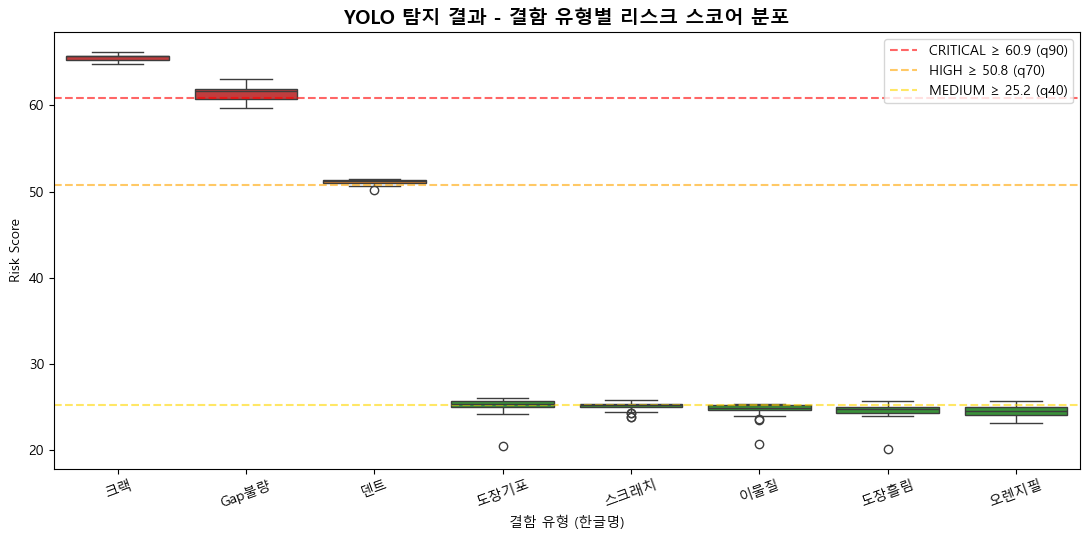

In [18]:
# 6-1. defect_type 별 risk_score boxplot
SEV_COLOR = {"CRITICAL": "#d62728", "MAJOR": "#ff7f0e", "MINOR": "#2ca02c"}

order_types = (
    risk_per_bbox.groupby("defect_type_name")["risk_score"]
    .median().sort_values(ascending=False).index.tolist()
)
palette = [
    SEV_COLOR.get(
        risk_per_bbox.loc[risk_per_bbox["defect_type_name"] == t, "severity"].iloc[0],
        "#888"
    )
    for t in order_types
]

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.boxplot(
    data=risk_per_bbox, x="defect_type_name", y="risk_score",
    order=order_types, palette=palette, ax=ax,
)
ax.set_title("YOLO 탐지 결과 - 결함 유형별 리스크 스코어 분포", fontsize=14, fontweight="bold")
ax.set_xlabel("결함 유형 (한글명)")
ax.set_ylabel("Risk Score")
ax.axhline(THRESH_Q90, ls="--", color="red",    alpha=0.6, label=f"CRITICAL ≥ {THRESH_Q90:.1f} (q90)")
ax.axhline(THRESH_Q70, ls="--", color="orange", alpha=0.6, label=f"HIGH ≥ {THRESH_Q70:.1f} (q70)")
ax.axhline(THRESH_Q40, ls="--", color="gold",   alpha=0.6, label=f"MEDIUM ≥ {THRESH_Q40:.1f} (q40)")
ax.legend(loc="upper right")
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()


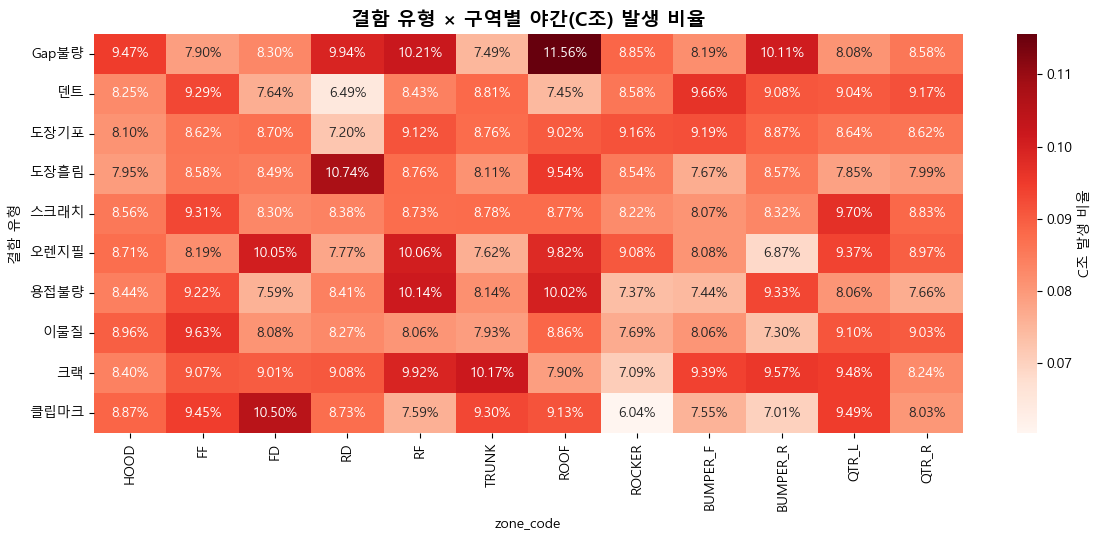

In [19]:
# 6-2. C조 발생 비율 히트맵
heat = profile_df.pivot_table(
    index="defect_type_name", columns="zone_code",
    values="shift_C_ratio", aggfunc="mean",
)
# zone 순서 가독성
zone_order = ["HOOD","FF","FD","RD","RF","TRUNK","ROOF","ROCKER",
              "BUMPER_F","BUMPER_R","QTR_L","QTR_R"]
heat = heat.reindex(columns=[c for c in zone_order if c in heat.columns])

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.heatmap(
    heat, annot=True, fmt=".2%", cmap="Reds",
    cbar_kws={"label": "C조 발생 비율"}, ax=ax,
)
ax.set_title("결함 유형 × 구역별 야간(C조) 발생 비율", fontsize=14, fontweight="bold")
ax.set_xlabel("zone_code")
ax.set_ylabel("결함 유형")
plt.tight_layout(); plt.show()


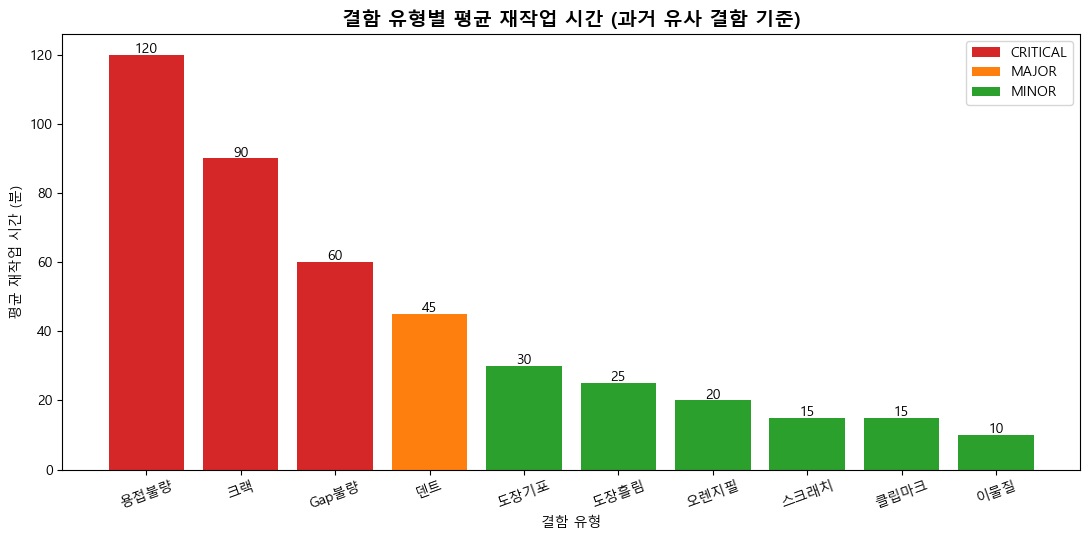

In [20]:
# 6-3. 평균 재작업 시간 (defect_type)
rew = (
    profile_df.groupby(["defect_type_name", "severity"], observed=True)
    .agg(avg_rework=("avg_rework_min", "mean"))
    .reset_index()
    .sort_values("avg_rework", ascending=False)
)
colors = [SEV_COLOR.get(s, "#888") for s in rew["severity"]]

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(rew["defect_type_name"], rew["avg_rework"], color=colors)
ax.set_title("결함 유형별 평균 재작업 시간 (과거 유사 결함 기준)", fontsize=14, fontweight="bold")
ax.set_xlabel("결함 유형")
ax.set_ylabel("평균 재작업 시간 (분)")
for b, v in zip(bars, rew["avg_rework"]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, f"{v:.0f}", ha="center", fontsize=10)

# 범례
from matplotlib.patches import Patch
legend = [Patch(facecolor=c, label=l) for l, c in SEV_COLOR.items()]
ax.legend(handles=legend, loc="upper right")
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()


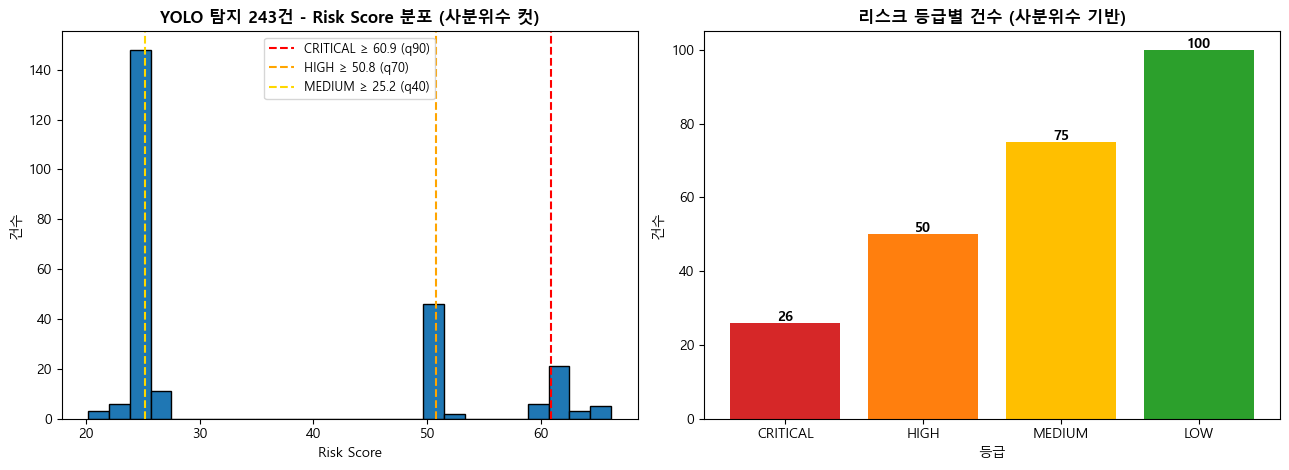

In [21]:
# 6-4. risk_score 히스토그램 + 등급 빈도
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].hist(risk_per_bbox["risk_score"], bins=25, color="#1f77b4", edgecolor="black")
axes[0].axvline(THRESH_Q90, color="red",    ls="--", label=f"CRITICAL ≥ {THRESH_Q90:.1f} (q90)")
axes[0].axvline(THRESH_Q70, color="orange", ls="--", label=f"HIGH ≥ {THRESH_Q70:.1f} (q70)")
axes[0].axvline(THRESH_Q40, color="gold",   ls="--", label=f"MEDIUM ≥ {THRESH_Q40:.1f} (q40)")
axes[0].set_title("YOLO 탐지 243건 - Risk Score 분포 (사분위수 컷)", fontweight="bold")
axes[0].set_xlabel("Risk Score"); axes[0].set_ylabel("건수")
axes[0].legend(fontsize=9)

GRADE_COLOR = {"CRITICAL": "#d62728", "HIGH": "#ff7f0e",
               "MEDIUM": "#ffbf00",   "LOW": "#2ca02c"}
gc = grade_counts
axes[1].bar(gc.index, gc.values, color=[GRADE_COLOR[g] for g in gc.index])
for i, v in enumerate(gc.values):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontweight="bold")
axes[1].set_title("리스크 등급별 건수 (사분위수 기반)", fontweight="bold")
axes[1].set_xlabel("등급"); axes[1].set_ylabel("건수")
plt.tight_layout(); plt.show()


## Step 7 - 통합 시연 시나리오 (Phase 3 미리보기)

CRITICAL / HIGH / LOW 각 1건씩 골라 end-to-end 출력.
권고 조치(Recommendation) 도 등급별로 매핑해 보여준다.


In [22]:
# 7-1. 권고 조치 매핑
RECOMMEND = {
    "CRITICAL": "즉시 라인 정지 및 전수 재검사",
    "HIGH":     "교대 시작 직후 집중 모니터링 / 습도 25% 이상 유지",
    "MEDIUM":   "당일 내 재작업 스케줄링",
    "LOW":      "정기 모니터링 유지",
}

def pick_one(grade_name):
    sub = risk_per_bbox[risk_per_bbox["risk_grade"] == grade_name]
    if len(sub) == 0:
        return None
    # 등급 안에서 score 중간값 근처 선택
    target = sub["risk_score"].median()
    idx = (sub["risk_score"] - target).abs().idxmin()
    return sub.loc[idx]

samples = []
for g in ["CRITICAL", "HIGH", "LOW"]:
    s = pick_one(g)
    if s is not None:
        samples.append(s)
print(f"선택된 샘플 수: {len(samples)}")


선택된 샘플 수: 3


In [23]:
# 7-2. end-to-end 출력
def fmt_pct(x):
    return f"{x*100:.1f}%" if pd.notna(x) else "N/A"

def report(row):
    lines = []
    lines.append("=" * 60)
    lines.append(f"이미지: {row['image_file']}")
    lines.append("=" * 60)
    lines.append("[YOLO 탐지]")
    lines.append(
        f"  결함: {row['defect_type_name']}({row['defect_type_code']})"
        f" | 구역: {row['zone']}"
        f" | 신뢰도: {row['conf']:.2f}"
    )
    lines.append("")
    lines.append(f"[프로파일 조회 결과]   <- 유사 과거 결함 N={int(row['n_samples'])}건 기준")
    A, B, C = row["shift_A_ratio"], row["shift_B_ratio"], row["shift_C_ratio"]
    dominant = max([("A", A), ("B", B), ("C", C)], key=lambda t: t[1])
    lines.append(f"  주요 발생 교대조 : {dominant[0]}조 ({fmt_pct(dominant[1])})")
    lines.append(f"  저습도(<25%) 비율: {fmt_pct(row['low_humidity_ratio'])}")
    lines.append(f"  평균 재작업 시간 : {row['avg_rework_min']:.0f}분")
    lines.append(f"  재작업 필요 비율 : {fmt_pct(row['rework_required_ratio'])}")
    lines.append("")
    lines.append("[리스크 평가]")
    lines.append(f"  리스크 스코어 : {row['risk_score']:.2f}  ->  등급: {row['risk_grade']}")
    lines.append(f"  권고 조치     : {RECOMMEND.get(row['risk_grade'], '-')}")
    lines.append("=" * 60)
    return "\n".join(lines)

for s in samples:
    print(report(s))
    print()


이미지: fender_bronze_000840.jpg
[YOLO 탐지]
  결함: Gap불량(GAP) | 구역: fender | 신뢰도: 0.49

[프로파일 조회 결과]   <- 유사 과거 결함 N=1147건 기준
  주요 발생 교대조 : B조 (45.8%)
  저습도(<25%) 비율: 0.7%
  평균 재작업 시간 : 60분
  재작업 필요 비율 : 100.0%

[리스크 평가]
  리스크 스코어 : 61.83  ->  등급: CRITICAL
  권고 조치     : 즉시 라인 정지 및 전수 재검사

이미지: rocker_bronze_000952.jpg
[YOLO 탐지]
  결함: 덴트(DNT) | 구역: rocker | 신뢰도: 0.94

[프로파일 조회 결과]   <- 유사 과거 결함 N=2155건 기준
  주요 발생 교대조 : A조 (47.4%)
  저습도(<25%) 비율: 0.8%
  평균 재작업 시간 : 45분
  재작업 필요 비율 : 100.0%

[리스크 평가]
  리스크 스코어 : 51.28  ->  등급: HIGH
  권고 조치     : 교대 시작 직후 집중 모니터링 / 습도 25% 이상 유지

이미지: front_door_navy_000818.jpg
[YOLO 탐지]
  결함: 이물질(DST) | 구역: front_door | 신뢰도: 0.84

[프로파일 조회 결과]   <- 유사 과거 결함 N=1398건 기준
  주요 발생 교대조 : A조 (48.2%)
  저습도(<25%) 비율: 1.0%
  평균 재작업 시간 : 10분
  재작업 필요 비율 : 30.4%

[리스크 평가]
  리스크 스코어 : 24.75  ->  등급: LOW
  권고 조치     : 정기 모니터링 유지



## Step 8 - 결과 요약 JSON 저장 (CLAUDE.md 업데이트용)

In [24]:
# 8-1. 핵심 인사이트 산출
# 리스크 스코어 가장 높은 결함 조합
highest = risk_per_bbox.sort_values("risk_score", ascending=False).iloc[0]
# C조 발생 비율 최고 조합 (profile 테이블 기준)
top_C = profile_df.sort_values("shift_C_ratio", ascending=False).iloc[0]

result = {
    "input_files": {
        "yolo": str(YOLO_CSV),
        "defect_detail_rows": int(len(defect_detail)),
        "yolo_total_rows": int(len(yolo_raw)),
        "yolo_detected_rows": int(len(yolo_df)),
        "yolo_empty_rows": int(len(yolo_empty)),
    },
    "profile_table": {
        "path": str(OUT_PROFILE),
        "rows": int(profile_df.shape[0]),
        "n_samples_min": int(profile_df["n_samples"].min()),
        "n_samples_max": int(profile_df["n_samples"].max()),
        "n_samples_median": int(profile_df["n_samples"].median()),
        "defect_types": int(profile_df["defect_type_code"].nunique()),
        "zones": int(profile_df["zone_code"].nunique()),
    },
    "mapping": {
        "yolo_detections": int(len(yolo_df)),
        "exploded_rows": int(len(yolo_profile)),
        "success_rate": float(success_rate),
        "fail_rows": int((~mapped_mask).sum()),
    },
    "risk_distribution": {
        "CRITICAL": int(grade_counts.get("CRITICAL", 0)),
        "HIGH":     int(grade_counts.get("HIGH",     0)),
        "MEDIUM":   int(grade_counts.get("MEDIUM",   0)),
        "LOW":      int(grade_counts.get("LOW",      0)),
        "mean_score": round(float(risk_per_bbox["risk_score"].mean()), 2),
        "max_score":  round(float(risk_per_bbox["risk_score"].max()),  2),
        "min_score":  round(float(risk_per_bbox["risk_score"].min()),  2),
    },
    "highlights": {
        "highest_risk_detection": {
            "image_file": str(highest["image_file"]),
            "defect_type": str(highest["defect_type_name"]),
            "zone": str(highest["zone"]),
            "risk_score": float(highest["risk_score"]),
            "risk_grade": str(highest["risk_grade"]),
        },
        "highest_C_shift_combo": {
            "defect_type": str(top_C["defect_type_name"]),
            "zone_code": str(top_C["zone_code"]),
            "shift_C_ratio": round(float(top_C["shift_C_ratio"]), 4),
            "n_samples": int(top_C["n_samples"]),
        },
    },
    "demo_samples": [
        {
            "image_file": str(s["image_file"]),
            "defect_type": str(s["defect_type_name"]),
            "zone": str(s["zone"]),
            "risk_score": float(s["risk_score"]),
            "risk_grade": str(s["risk_grade"]),
        } for s in samples
    ],
}

with open(OUT_RESULT_JSON, "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)
print(f"저장: {OUT_RESULT_JSON}")
print(json.dumps(result, ensure_ascii=False, indent=2))


저장: C:\Users\user\Desktop\PROJ2\_profile_result.json
{
  "input_files": {
    "yolo": "C:\\Users\\user\\Desktop\\PROJ2\\yolo_inference_results.csv",
    "defect_detail_rows": 170904,
    "yolo_total_rows": 289,
    "yolo_detected_rows": 251,
    "yolo_empty_rows": 38
  },
  "profile_table": {
    "path": "C:\\Users\\user\\Desktop\\PROJ2\\defect_profile_table.csv",
    "rows": 120,
    "n_samples_min": 393,
    "n_samples_max": 3692,
    "n_samples_median": 1295,
    "defect_types": 10,
    "zones": 12
  },
  "mapping": {
    "yolo_detections": 251,
    "exploded_rows": 326,
    "success_rate": 1.0,
    "fail_rows": 0
  },
  "risk_distribution": {
    "CRITICAL": 26,
    "HIGH": 50,
    "MEDIUM": 75,
    "LOW": 100,
    "mean_score": 35.1,
    "max_score": 66.19,
    "min_score": 20.15
  },
  "highlights": {
    "highest_risk_detection": {
      "image_file": "trunk_silver_000878.jpg",
      "defect_type": "크랙",
      "zone": "trunk",
      "risk_score": 66.19,
      "risk_grade": "CRIT

## 최종 정리

### 산출물
| 파일 | 설명 |
|---|---|
| `defect_profile_table.csv` | defect_type × zone 프로파일 테이블 (정형 DB 집계) |
| `_profile_result.json` | 매핑/리스크 결과 요약 (CLAUDE.md 업데이트용) |
| `model_profile_mapping.ipynb` | 본 노트북 |

### 핵심
1. **인스턴스 직접 조인 불가**라는 한계를 **프로파일 레벨 매핑**으로 우회.
2. YOLO 탐지 1건을 `(defect_type, zone)` 키로 정형 프로파일에 조회 → 과거 결함 통계가 즉시 따라붙음.
3. 5개 요소(심각도/야간/저습도/재작업/conf)로 **리스크 스코어 0~100** 산출, **CRITICAL/HIGH/MEDIUM/LOW** 4등급 분류.
4. Phase 3 (Streamlit 대시보드) 의 핵심 데이터 계층 완료.


## PaintGuard 프로젝트 총평
> Phase 1-A / 1-B / 2 전 단계 완료 기준

---

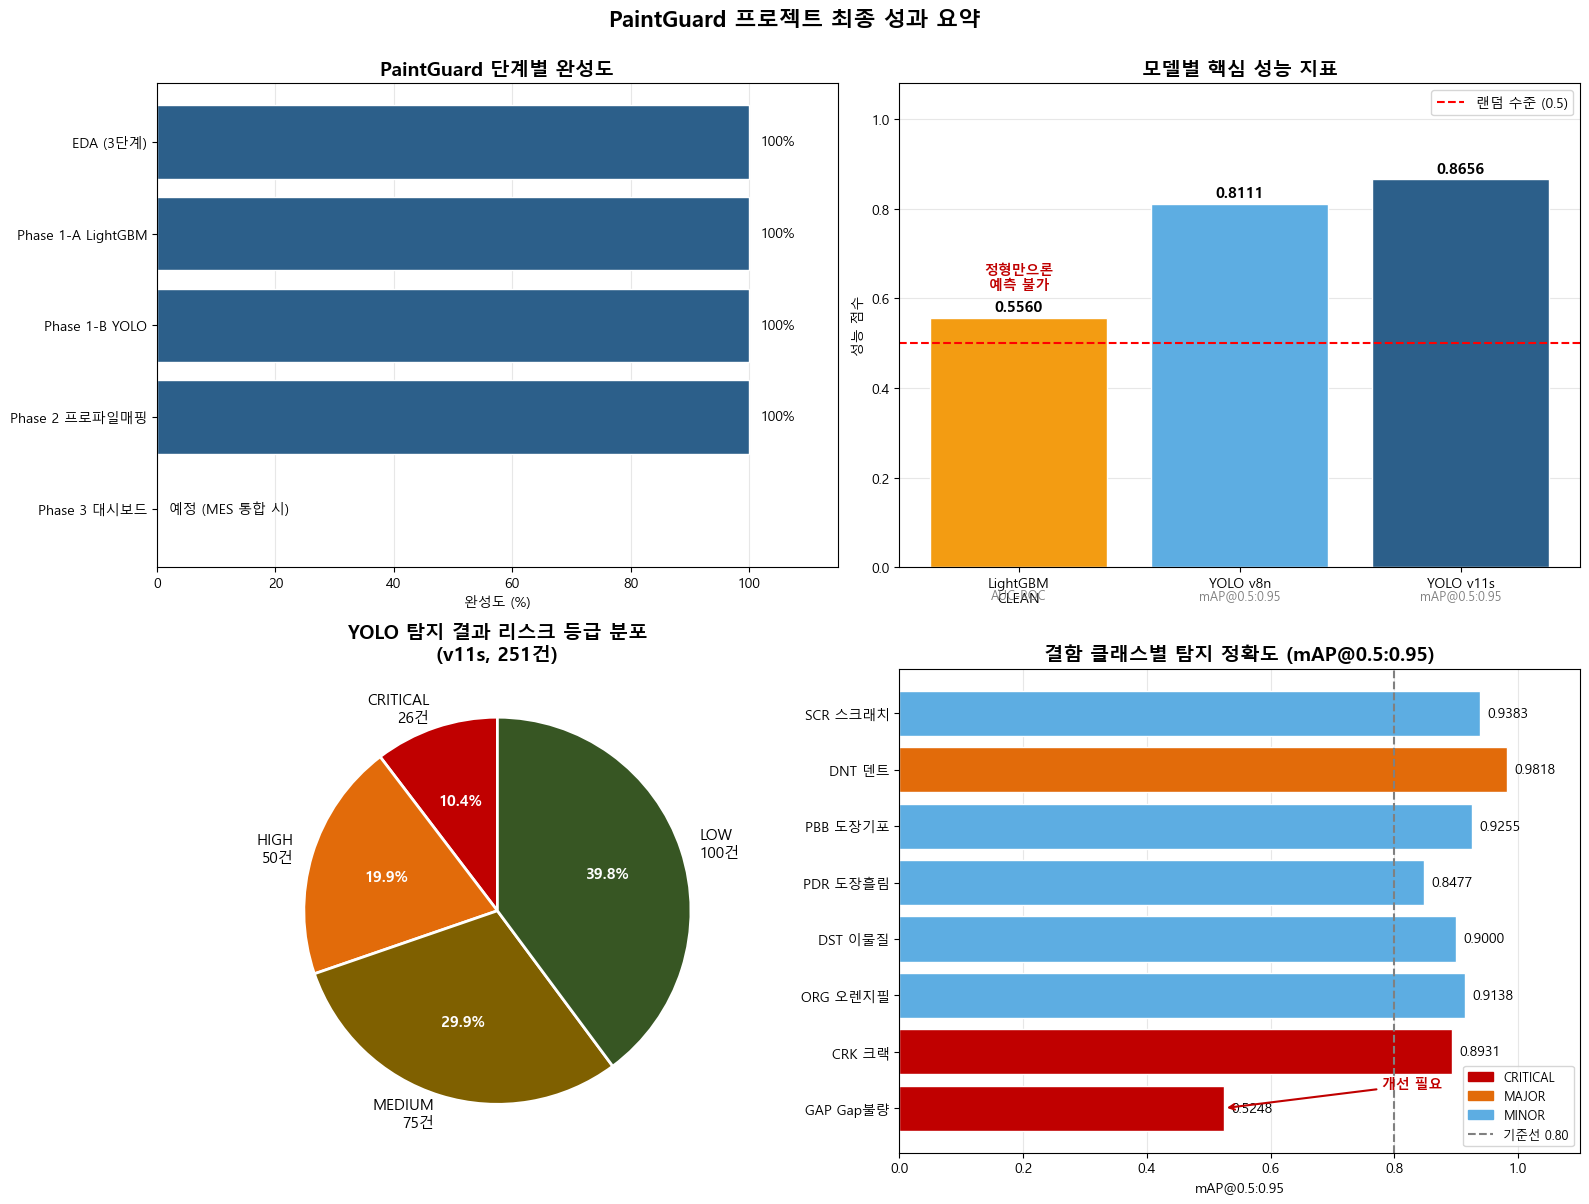

Saved: C:/Users/user/Desktop/PROJ2/paintguard_final_summary.png


In [25]:
# PaintGuard 프로젝트 최종 성과 요약 시각화
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
import numpy as np

rcParams["font.family"] = "Malgun Gothic"
rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor="white")

# ---------- 차트 1 (좌상): 단계별 완성도 ----------
ax1 = axes[0, 0]
phases = ["EDA (3단계)", "Phase 1-A LightGBM", "Phase 1-B YOLO",
          "Phase 2 프로파일매핑", "Phase 3 대시보드"]
completion = [100, 100, 100, 100, 0]
colors1 = ["#2C5F8A" if v == 100 else "#CCCCCC" for v in completion]
y_pos = np.arange(len(phases))
bars1 = ax1.barh(y_pos, completion, color=colors1, edgecolor="white")
ax1.set_yticks(y_pos)
ax1.set_yticklabels(phases)
ax1.invert_yaxis()
ax1.set_xlim(0, 115)
ax1.set_xlabel("완성도 (%)")
ax1.set_title("PaintGuard 단계별 완성도", fontsize=14, fontweight="bold")
for bar, val in zip(bars1, completion):
    label = f"{val}%" if val > 0 else "예정 (MES 통합 시)"
    ax1.text(val + 2, bar.get_y() + bar.get_height() / 2, label,
             va="center", fontsize=10)
ax1.grid(axis="x", alpha=0.3)
ax1.set_axisbelow(True)

# ---------- 차트 2 (우상): 모델별 핵심 성능 지표 ----------
ax2 = axes[0, 1]
models = ["LightGBM\nCLEAN", "YOLO v8n", "YOLO v11s"]
scores = [0.556, 0.8111, 0.8656]
colors2 = ["#F39C12", "#5DADE2", "#2C5F8A"]
bars2 = ax2.bar(models, scores, color=colors2, edgecolor="white")
ax2.axhline(y=0.5, color="red", linestyle="--", linewidth=1.5,
            label="랜덤 수준 (0.5)")
ax2.set_ylim(0, 1.08)
ax2.set_ylabel("성능 점수")
ax2.set_title("모델별 핵심 성능 지표", fontsize=14, fontweight="bold")
for bar, val in zip(bars2, scores):
    ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.015,
             f"{val:.4f}", ha="center", fontsize=11, fontweight="bold")
# 지표 이름 주석
metric_names = ["AUC-ROC", "mAP@0.5:0.95", "mAP@0.5:0.95"]
for i, m in enumerate(metric_names):
    ax2.text(i, -0.065, m, ha="center", fontsize=9, color="gray",
             transform=ax2.get_xaxis_transform())
# LightGBM 막대 위 텍스트
ax2.text(0, 0.62, "정형만으론\n예측 불가", ha="center", fontsize=10,
         color="#C00000", fontweight="bold")
ax2.legend(loc="upper right")
ax2.grid(axis="y", alpha=0.3)
ax2.set_axisbelow(True)

# ---------- 차트 3 (좌하): 리스크 등급 분포 pie ----------
ax3 = axes[1, 0]
grades = ["CRITICAL\n26건", "HIGH\n50건", "MEDIUM\n75건", "LOW\n100건"]
sizes = [26, 50, 75, 100]
colors3 = ["#C00000", "#E26B0A", "#7F6000", "#375623"]
wedges, texts, autotexts = ax3.pie(
    sizes, labels=grades, colors=colors3,
    autopct="%.1f%%", startangle=90,
    textprops={"fontsize": 11},
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
for at in autotexts:
    at.set_color("white")
    at.set_fontweight("bold")
    at.set_fontsize(11)
ax3.set_title("YOLO 탐지 결과 리스크 등급 분포\n(v11s, 251건)",
              fontsize=14, fontweight="bold")

# ---------- 차트 4 (우하): 결함 유형별 mAP@0.5:0.95 ----------
ax4 = axes[1, 1]
defects = ["SCR 스크래치", "DNT 덴트", "PBB 도장기포", "PDR 도장흘림",
           "DST 이물질", "ORG 오렌지필", "CRK 크랙", "GAP Gap불량"]
maps = [0.9383, 0.9818, 0.9255, 0.8477, 0.9000, 0.9138, 0.8931, 0.5248]
severity = {
    "SCR 스크래치": "MINOR",
    "DNT 덴트":     "MAJOR",
    "PBB 도장기포": "MINOR",
    "PDR 도장흘림": "MINOR",
    "DST 이물질":   "MINOR",
    "ORG 오렌지필": "MINOR",
    "CRK 크랙":     "CRITICAL",
    "GAP Gap불량":  "CRITICAL",
}
sev_color = {"CRITICAL": "#C00000", "MAJOR": "#E26B0A", "MINOR": "#5DADE2"}
colors4 = [sev_color[severity[d]] for d in defects]
y_pos4 = np.arange(len(defects))
bars4 = ax4.barh(y_pos4, maps, color=colors4, edgecolor="white")
ax4.axvline(x=0.8, color="gray", linestyle="--", linewidth=1.5,
            label="기준선 0.80")
ax4.set_yticks(y_pos4)
ax4.set_yticklabels(defects)
ax4.invert_yaxis()
ax4.set_xlim(0, 1.1)
ax4.set_xlabel("mAP@0.5:0.95")
ax4.set_title("결함 클래스별 탐지 정확도 (mAP@0.5:0.95)",
              fontsize=14, fontweight="bold")
for bar, val in zip(bars4, maps):
    ax4.text(val + 0.012, bar.get_y() + bar.get_height() / 2,
             f"{val:.4f}", va="center", fontsize=10)
# GAP 주석
gap_idx = defects.index("GAP Gap불량")
ax4.annotate("개선 필요",
             xy=(0.5248, gap_idx),
             xytext=(0.78, gap_idx - 0.35),
             fontsize=10, color="#C00000", fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="#C00000", lw=1.5))
legend_handles = [
    mpatches.Patch(color="#C00000", label="CRITICAL"),
    mpatches.Patch(color="#E26B0A", label="MAJOR"),
    mpatches.Patch(color="#5DADE2", label="MINOR"),
    plt.Line2D([0], [0], color="gray", linestyle="--", label="기준선 0.80"),
]
ax4.legend(handles=legend_handles, loc="lower right", fontsize=9)
ax4.grid(axis="x", alpha=0.3)
ax4.set_axisbelow(True)

fig.suptitle("PaintGuard 프로젝트 최종 성과 요약",
             fontsize=16, fontweight="bold", y=1.00)
plt.tight_layout()

OUT_PNG = r"C:/Users/user/Desktop/PROJ2/paintguard_final_summary.png"
plt.savefig(OUT_PNG, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {OUT_PNG}")


### 수치 성과 요약

| 구분 | 항목 | 결과 | 비고 |
|---|---|---|---|
| 데이터 | 정형 데이터 | 300만행, Null 0%, FK 100% | 완벽한 품질 |
| 데이터 | 이미지 | 1,000장, 8클래스 | YOLO 라벨 포함 |
| EDA | 핵심 인사이트 | C조 6.02% / 교대직후 6.08% / 저습도 4.3~4.5% | 3가지 패턴 확인 |
| Phase 1-A | LightGBM AUC | 0.556 (≈ 랜덤) | 정형만으론 예측 불가 확인 |
| Phase 1-A | SHAP 1위 피처 | `shift_hour` (2위 대비 20배) | EDA 인사이트 모델로 재확인 |
| Phase 1-B | YOLO v11s mAP@0.5 | 0.9875 | 8클래스 전부 0.93 이상 |
| Phase 1-B | YOLO v11s mAP@0.5:0.95 | 0.8656 | v8n 대비 +6.7% 개선 |
| Phase 1-B | 색상 분류 Top-1 Acc | 1.0000 | 9클래스 완벽 분리 |
| Phase 2 | 프로파일 매핑 성공률 | 100% (251건 전건) | 인스턴스 조인 없이 달성 |
| Phase 2 | 리스크 CRITICAL 건수 | 26건 (10.4%) | 분위수 자동 조정 방식 |

## 총평

### 1. 데이터 한계를 방법론으로 극복
이미지와 정형 데이터 사이에 공유 키가 없어 인스턴스 레벨 직접 조인이
불가능했다. 이를 **"프로파일 레벨 매핑"** 방식으로 우회하여
`결함 유형 × 구역` 조합으로 과거 공정 이력을 조회하는 구조를 설계했다.

### 2. 두 파이프라인의 상호 보완
- 정형 모델(LightGBM AUC 0.556)은 FAIL 예측에 실패했으나,
  이 결과 자체가 **"이미지 트랙이 필요하다"는 근거**가 되었다.
- YOLO(mAP@0.5:0.95 = 0.866)는 이미지에서 결함을 성공적으로 탐지했고,
  그 결과를 정형 데이터 기반 프로파일과 연결해 공정 맥락을 부여했다.
- 두 트랙이 독립적으로 성립하면서 동시에 서로를 보완하는 구조다.

### 3. 한계 및 향후 방향
- **GAP(Gap불량) mAP@0.5:0.95 = 0.5248** — 얇고 길쭉한 bbox 회귀 한계.
  SIoU loss 또는 oversampling으로 개선 가능.
- 합성 데이터 기반이므로 실제 공정 데이터로 재검증 필요.
- Phase 3 (MES 통합 대시보드)에서 생산량/공정/품질/예지보전
  4개 레이어를 통합하여 시연할 예정.

### 4. MES 시스템 내 위치
본 프로젝트(**PaintGuard**)는 MES 4개 레이어 중
**공정 + 품질** 파트에 해당하며,
나머지 레이어(생산량, 예지보전) 완성 후
통합 대시보드로 연결될 예정이다.

---

*Phase 1-A / 1-B / 2 전 단계 완료. 본 노트북은 Phase 2 최종 산출물.*

### 5. 추론 플로우 — 구현 준비 완료

본 프로젝트에서 구축한 파이프라인은 아래 순서로 실시간 동작 가능하다.

```
이미지 1장 입력
  → 결함 탐지 (YOLOv11s-detect) + 색상 분류 (YOLOv11s-cls) 동시 실행
  → 결함 유형 + bbox + 색상 + 심각도 확정
  → 프로파일 테이블 조회 ("유사 과거 결함은 C조, 저습도에서 빈발")
  → 리스크 스코어 + 등급 산출
  → 권고 조치 출력 ("즉시 라인 정지" / "집중 모니터링" 등)
  → 재작업 예상 비용(시간) 표시
```

필요한 모델 파일과 데이터 계층이 전부 준비된 상태이며,
웹 구현(Streamlit 또는 동등한 프레임워크)으로 즉시 확장 가능하다.

### 6. MES 시스템 내 위치 및 다음 단계

PaintGuard는 MES(Manufacturing Execution System) 4개 레이어 중
**공정 + 품질** 파트에 해당한다.

| MES 레이어 | 내용 | 상태 |
|---|---|---|
| 생산량 | 생산 실적, 목표 대비 달성률 | 미개발 |
| **공정** | **AI 비전 결함 탐지, 리스크 평가** | **완료 (PaintGuard)** |
| **품질** | **프로파일 매핑, 권고 조치** | **완료 (PaintGuard)** |
| 예지보전 | 설비 이상 예측, 교체 주기 관리 | 미개발 |

나머지 레이어(생산량, 예지보전) 완성 후
4개 레이어를 통합한 **MES 통합 대시보드**를 구현할 예정이다.